# Module 4 scikit-learn

## Section 4.A Intro to Predictive Analysis

### 4.A.1 What is machine learning?

- **Machine learning** is teaching a computer to find patterns in data and use those to make predictions or descisions

- There are two broad categories:
    - **Supervised learning**: you provide labeled exampled, and the model learns to predict the answers for new input
    - **Unsupervised learning**: you provide data with labels, and the model finds structure or grouping on its own

- ML helps answer this question "What can I predict from this data?"

### 4.A.2 The estimator API

- Every model in scikit-learn follows the same three step interface

- Method:
    - .fit(X, y): Trains the model on your data
    - .predict(X): Uses the trained model to generate predictions
    - .score(X, y): Evaluates model accuracy

### 4.A.3 Preparing your data 

- scikit-learn models expect data in a specific format:
    - **Feature matrix X**: a 2D array or DataFrame of input columns (the things you are using to make a prediction)
    - **Target vector y**: a 1D or Series of the values you want to predict.

- It's good practice to split data into two sets:
    - **Training set**: the data the model learns from
    - **Test set**: data held back to evaluate how well the model performs on new, unseen examples

- To split, use *train_test_split()* from *sklearn.model_selection*

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state =42)

- *test_size=0.2* reserves 20% of the data for testing; 80% goes to training
- *random_state=42* sets a seed so the split is reproducible

## Section 4.B Linear Regression

### 4.B.1 When to use linear regression

- Use linear regression when:
    - The outcome you want to predict is a continuous number
    - You expect a rough linear relationship between your input and that outcome

### 4.B.2 Building and fitting a model

- From the sample script **linear_regression_example.py**:

In [5]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# Sample dataset: hours studied vs. exam score
data = {
'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
'exam_score': [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)
# Step 1: Define features (X) and target (y)
X = df[['hours_studied']] # 2D: double brackets give a DataFrame
y = df['exam_score'] # 1D: single brackets give a Series
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


### 4.B.3 Making predictions

- Modify the sampe scripts to make some predictions:

In [6]:
# Predict exam scores for the test set
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

# Inspect what the model learned
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]

Slope (coefficient): 4.10
Intercept: 47.68


- *model.coef_* is the slope(s) of the regression line: here it tells you: "for each additional hour studied, the predicted score increased by this many points

- *model.intercept_* is the predicted score when all inputs equal zero

### 4.B.4 Evaluating the model

In [7]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


- **R^2 (R-squared)** measure how much of the variation in your target variable is explained by your model:
    - **= 1.0 -->** perfect prediction; the model explains all variation in the data
    - **= 0.0 -->** the model has no predictive value; it performs no better than always predicting the average
    - **= 0.85 -->** the model explains 85% of the variation; 15% remains unexplained

### 4.B.5 Visualizing actual vs. predicted

C:\Users\kevintran\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


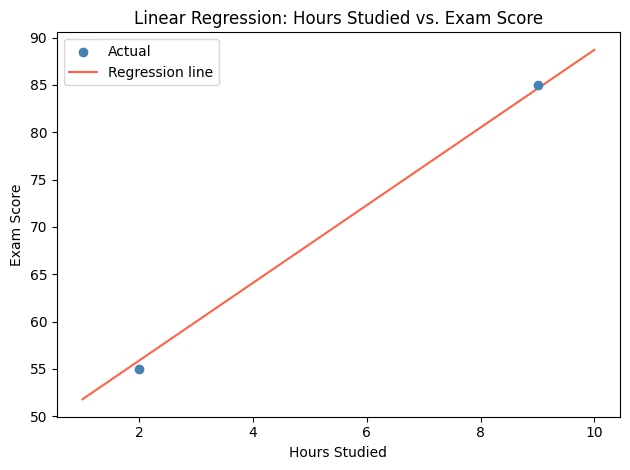

In [8]:
import matplotlib.pyplot as plt

# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# Line: model predictions across the full range of X
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout() # adjusts spacing so labels and titles don't overlap
plt.show()